# NLP Project for Disaster Tweet Classification

## Project Introduction

* Social media platforms such as Twitter play an important role in sharing real-time information during emergencies and disasters.

* This project aims to develop a Natural Language Processing (NLP) based Machine Learning model that can classify tweets as either disaster-related or non-disaster-related. 
    
* The project includes data exploration, text preprocessing, feature engineering, model development, evaluation, validation, and deployment through a web interface.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Required libraries imported successfully.")

Required libraries imported successfully.


# Set Project Working Directory

In [2]:
import os

project_path = r"D:\Internship Projects\Project 7"
os.chdir(project_path)

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
D:\Internship Projects\Project 7


# Load the Dataset

In [3]:
df = pd.read_csv("twitter_disaster.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


# Check Dataset Shape

In [5]:
rows, columns = df.shape

print(f"Total Number of Rows    : {rows}")
print(f"Total Number of Columns : {columns}")

Total Number of Rows    : 7613
Total Number of Columns : 5


# Check Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


# Check Statistical and Categorical Summary

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,7613.0,NaN,NaN,NaN,5441.934848,3137.11609,1.0,2734.0,5408.0,8146.0,10873.0
keyword,7552,221,fatalities,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,5080,3341,USA,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,7613,7503,11-Year-Old Boy Charged With Manslaughter of T...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,7613.0,NaN,NaN,NaN,0.42966,0.49506,0.0,0.0,0.0,1.0,1.0


# Check Missing Value

In [8]:
missing_summary = pd.DataFrame({"Missing Values": df.isnull().sum(), "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)})

missing_summary

,Missing Values,Missing Percentage (%)
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


* Missing values are mainly present in the **location** column while the **keyword** column has only a few missing values.

* The important **text** and **target** columns have no missing values.

# Check Duplicate Values & Repeated Tweet Texts

In [9]:
# Check for duplicated rows
duplicate_rows = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_rows}")

# Check for repeated tweet text
duplicate_text_count = df.duplicated(subset="text").sum()

print(f"Number of Repeated Tweet Texts: {duplicate_text_count}")

Number of Duplicate Rows: 0
Number of Repeated Tweet Texts: 110


# Target Class Validation

In [10]:
target_summary = df["target"].value_counts().sort_index()

print("Target Class Distribution:")
print(target_summary)

Target Class Distribution:
target
0    4342
1    3271
Name: count, dtype: int64


* The target column contains two valid classes: **0** for non-disaster and **1** for disaster tweets.

* Both classes contain enough observations for binary classification.

# Exploratory Data Analysis

## Univariate Analysis

### Target Class Distribution

In [11]:
target_counts = df["target"].value_counts().sort_index()

target_distribution = pd.DataFrame({"Category": ["Non-Disaster", "Disaster"], "Count": target_counts.values,
                                    "Percentage": (target_counts.values / len(df) * 100).round(2)})

target_distribution

,Category,Count,Percentage
0,Non-Disaster,4342,57.03
1,Disaster,3271,42.97


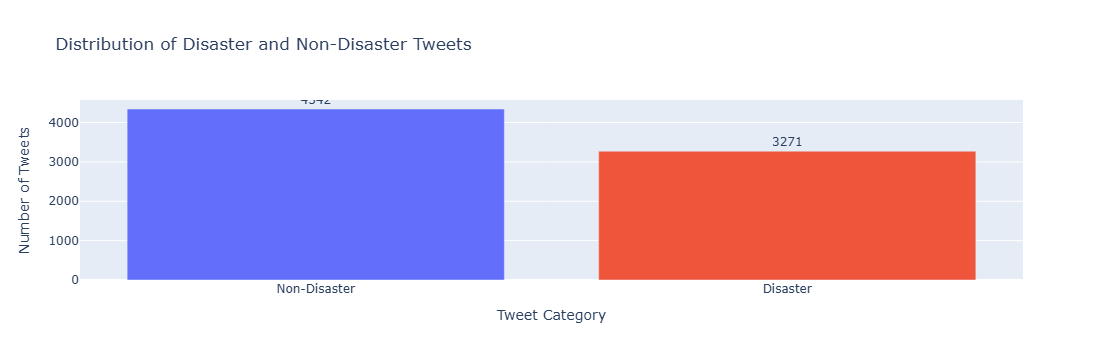

In [12]:
fig = px.bar(target_distribution, x = "Category", y = "Count", color = "Category", text = "Count", 
             title = "Distribution of Disaster and Non-Disaster Tweets")

fig.update_traces(textposition = "outside")

fig.update_layout(xaxis_title = "Tweet Category", yaxis_title = "Number of Tweets", showlegend = False)

fig.show()

* The dataset contains **4,342 non-disaster tweets** and **3,271 disaster tweets**, showing a higher number of non-disaster tweets.

* The class distribution is moderately balanced, although non-disaster tweets form the larger group.

### Top Keywords Analysis

In [13]:
top_keywords = (df["keyword"].dropna().value_counts().head(15).reset_index())

top_keywords.columns = ["Keyword", "Frequency"]

top_keywords

,Keyword,Frequency
0,fatalities,45
1,deluge,42
2,armageddon,42
3,sinking,41
4,damage,41
5,harm,41
6,body%20bags,41
7,outbreak,40
8,evacuate,40
9,fear,40


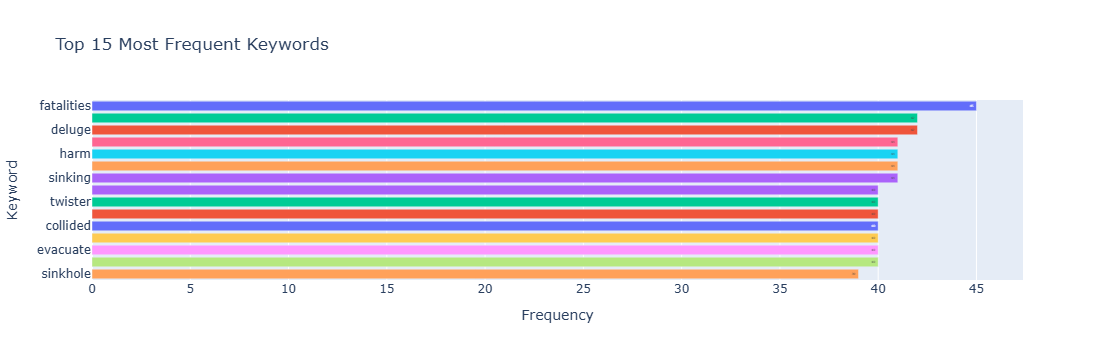

In [14]:
fig = px.bar(top_keywords, x = "Frequency", y = "Keyword", color = "Keyword", text = "Frequency", orientation = "h",
             title = "Top 15 Most Frequent Keywords")

fig.update_layout(xaxis_title = "Frequency", yaxis_title = "Keyword", showlegend = False, yaxis = {"categoryorder": "total ascending"})

fig.show()

* **fatalities** is the most frequent keyword with **45 occurrences** while most other top keywords appear around 40–42 times.

* Keywords such as **deluge, harm, sinking, collided and evacuate** indicate that disaster-related terms are commonly represented in the dataset.

### Tweet Length Distribution

In [15]:
df["tweet_length"] = df["text"].astype(str).apply(len)

df["tweet_length"].describe().round(2)

count    7613.00
mean      101.04
std        33.78
min         7.00
25%        78.00
50%       107.00
75%       133.00
max       157.00
Name: tweet_length, dtype: float64

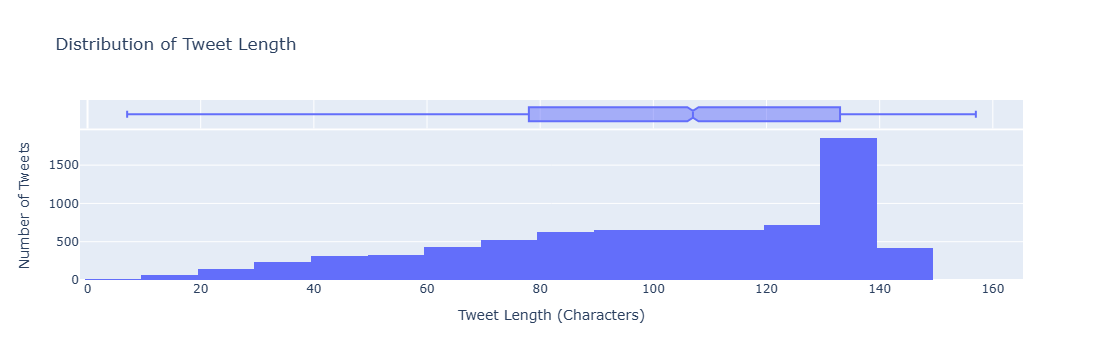

In [16]:
fig = px.histogram(df, x = "tweet_length", nbins = 30, marginal = "box", title = "Distribution of Tweet Length")

fig.update_layout(xaxis_title = "Tweet Length (Characters)", yaxis_title = "Number of Tweets")

fig.show()

* Most tweets are concentrated in the higher character-length range particularly around **80 to 140 characters**.

* A noticeable concentration of tweets appears near **130 to 140 characters** while shorter tweets occur less frequently.

### Word Count Distribution

In [17]:
df["word_count"] = df["text"].astype(str).apply(lambda text: len(text.split()))

df["word_count"].describe().round(2)

count    7613.00
mean       14.90
std         5.73
min         1.00
25%        11.00
50%        15.00
75%        19.00
max        31.00
Name: word_count, dtype: float64

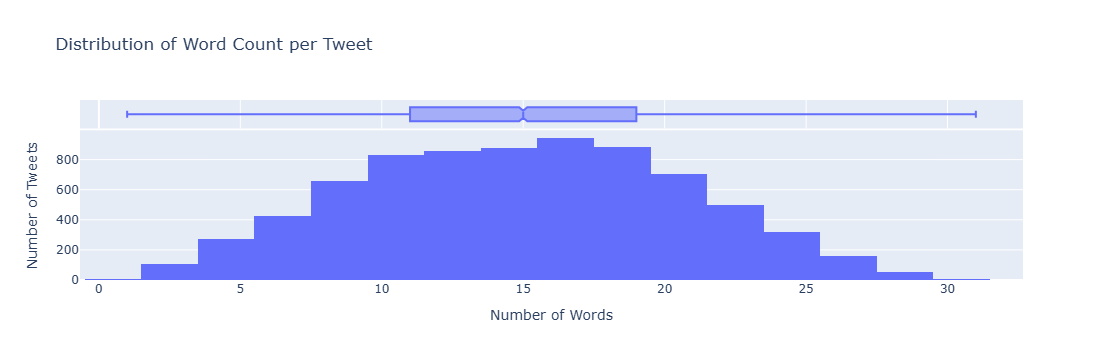

In [18]:
fig = px.histogram(df, x = "word_count", nbins = 25, marginal = "box", title = "Distribution of Word Count per Tweet")

fig.update_layout(xaxis_title = "Number of Words", yaxis_title = "Number of Tweets")

fig.show()

* Most tweets contain approximately **10 to 20 words** with the highest concentration around **15 to 18 words**.

* Very short tweets and tweets containing more than **25 words** are comparatively less frequent.

## Bivariate Analysis

### Tweet Length vs Target

In [19]:
tweet_length_target = (df.groupby("target")["tweet_length"].agg(["mean", "median", "min", "max"]).round(2))

tweet_length_target.index = ["Non-Disaster", "Disaster"]
tweet_length_target

,mean,median,min,max
Non-Disaster,95.71,101.0,7,157
Disaster,108.11,115.0,14,151


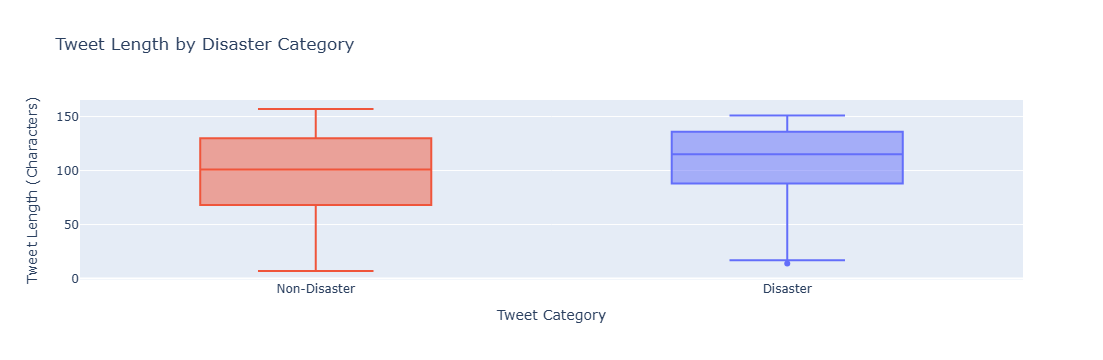

In [20]:
fig = px.box(df, x = "target", y = "tweet_length", color = "target", title = "Tweet Length by Disaster Category",
             labels = {"target": "Tweet Category", "tweet_length": "Tweet Length (Characters)"})

fig.update_xaxes(tickvals = [0, 1], ticktext = ["Non-Disaster", "Disaster"])

fig.update_layout(showlegend=False)

fig.show()

* Disaster tweets generally have a higher median tweet length than non-disaster tweets.

* Non-disaster tweets show a wider spread, especially toward shorter tweet lengths.

### Top Keywords by Target Class

In [21]:
top_10_keywords = df["keyword"].value_counts().head(10).index

keyword_target_data = (df[df["keyword"].isin(top_10_keywords)].groupby(["keyword", "target"]).size().reset_index(name = "Count"))

keyword_target_data["Category"] = keyword_target_data["target"].map({0: "Non-Disaster", 1: "Disaster"})

keyword_target_data.head()

,keyword,target,Count,Category
0,armageddon,0,37,Non-Disaster
1,armageddon,1,5,Disaster
2,body%20bags,0,40,Non-Disaster
3,body%20bags,1,1,Disaster
4,damage,0,22,Non-Disaster


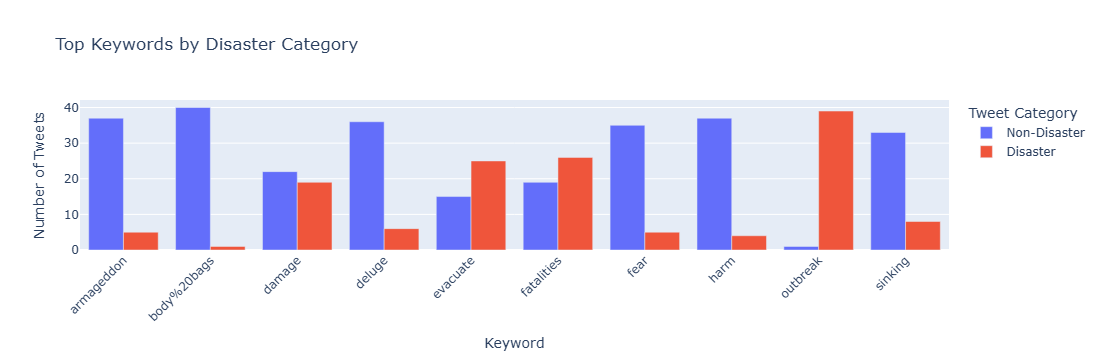

In [22]:
fig = px.bar(keyword_target_data, x = "keyword", y = "Count", color = "Category", barmode = "group", 
             title="Top Keywords by Disaster Category", labels={"keyword": "Keyword", "Count": "Number of Tweets",
                                                                "Category": "Tweet Category"})

fig.update_layout(xaxis_tickangle = -45)

fig.show()

* Keywords such as **outbreak, evacuate** and **fatalities** contain a higher proportion of disaster tweets.

* In contrast keywords such as **body%20bags, armageddon, harm** and **deluge** appear mainly in non-disaster tweets.

### URL Presence vs Target

In [23]:
df["has_url"] = df["text"].astype(str).str.contains(r"http\S+|www\.\S+", regex = True)

url_target = (pd.crosstab(df["has_url"], df["target"]).reset_index())

url_target.columns = ["Has_URL", "Non-Disaster", "Disaster"]

url_target["Has_URL"] = url_target["Has_URL"].map({False: "No URL", True: "Contains URL"})

url_target

,Has_URL,Non-Disaster,Disaster
0,No URL,2543,1099
1,Contains URL,1799,2172


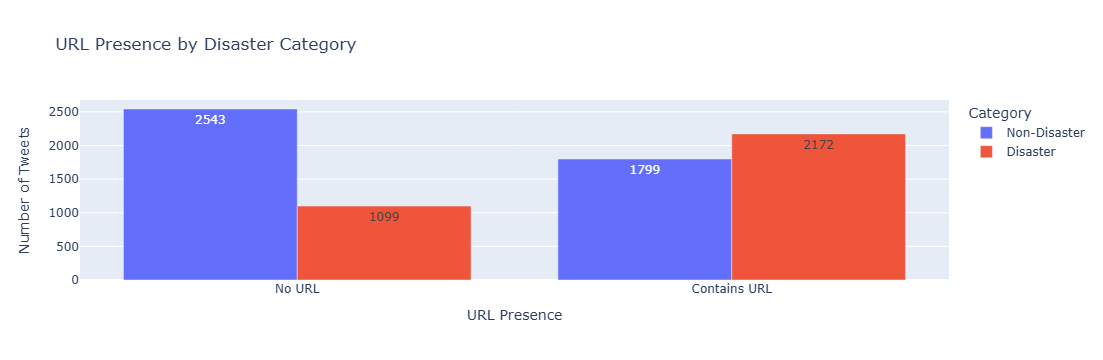

In [24]:
url_plot = url_target.melt(id_vars="Has_URL", value_vars=["Non-Disaster", "Disaster"], var_name="Category", value_name="Count")

fig = px.bar(url_plot, x = "Has_URL", y = "Count", color = "Category", barmode = "group", text = "Count", title="URL Presence by Disaster Category")

fig.update_layout(xaxis_title = "URL Presence", yaxis_title = "Number of Tweets")

fig.show()

* Tweets without URLs are predominantly non-disaster tweets with **2,543** non-disaster compared with **1,099** disaster tweets.

* Among tweets containing URLs, disaster tweets are more frequent with **2,172** disaster compared with **1,799** non-disaster tweets.    

## Multivariate Analysis

### Tweet Length, Word Count and Target

In [25]:
df["category"] = df["target"].map({0: "Non-Disaster", 1: "Disaster"})

# Display selected features
df[["tweet_length", "word_count", "category"]].head()

,tweet_length,word_count,category
0,69,13,Disaster
1,38,7,Disaster
2,133,22,Disaster
3,65,8,Disaster
4,88,16,Disaster


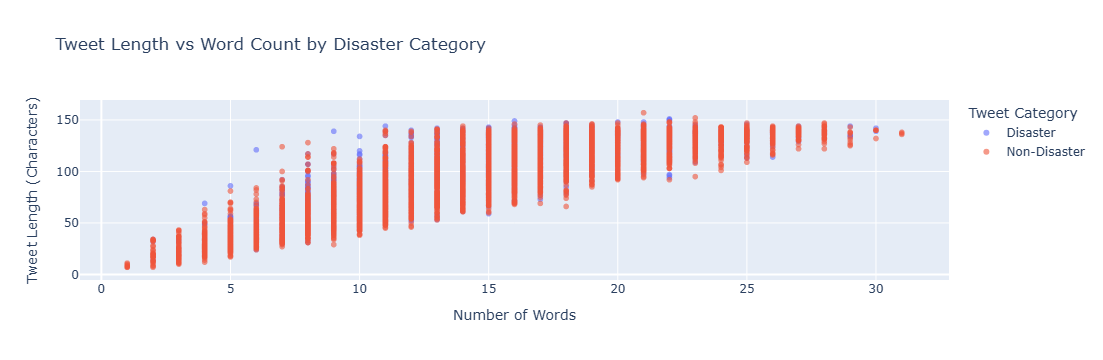

In [26]:
fig = px.scatter(df, x = "word_count", y = "tweet_length", color = "category", opacity = 0.6,
                 title="Tweet Length vs Word Count by Disaster Category", labels = {"word_count": "Number of Words",
                                                                                    "tweet_length": "Tweet Length (Characters)",
                                                                                    "category": "Tweet Category"})

fig.update_layout(legend_title = "Tweet Category")

fig.show()

* Tweet length and word count show a strong positive relationship as longer tweets generally contain more words.

* Disaster and non-disaster tweets overlap considerably across this relationship.

# Correlation Heatmap

## Feature Creation

In [27]:
# Create numerical text features
df["hashtag_count"] = df["text"].astype(str).apply(lambda text: len(re.findall(r"#\w+", text)))

df["mention_count"] = df["text"].astype(str).apply(lambda text: len(re.findall(r"@\w+", text)))

df["url_count"] = df["text"].astype(str).apply(lambda text: len(re.findall(r"http\S+|www\.\S+", text)))

# Select numerical features
numerical_features = ["tweet_length", "word_count", "hashtag_count", "mention_count", "url_count", "target"]

correlation_matrix = df[numerical_features].corr().round(2)

correlation_matrix

,tweet_length,word_count,hashtag_count,mention_count,url_count,target
tweet_length,1.00,0.84,0.21,0.06,0.30,0.18
word_count,0.84,1.00,0.04,0.04,-0.12,0.04
hashtag_count,0.21,0.04,1.00,-0.04,0.17,0.05
mention_count,0.06,0.04,-0.04,1.00,-0.22,-0.10
url_count,0.30,-0.12,0.17,-0.22,1.00,0.20
target,0.18,0.04,0.05,-0.10,0.20,1.00


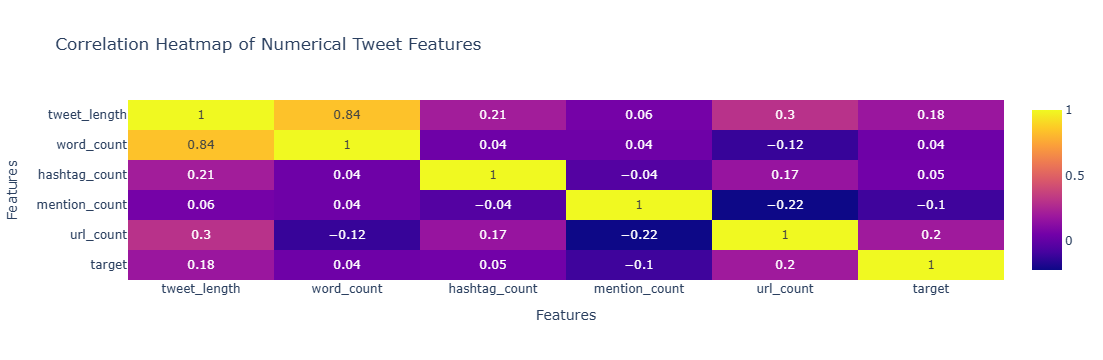

In [28]:
fig = px.imshow(correlation_matrix, text_auto = True, aspect = "auto", title = "Correlation Heatmap of Numerical Tweet Features")

fig.update_layout(xaxis_title = "Features", yaxis_title = "Features")

fig.show()

* Tweet length and word count have a strong positive correlation of **0.84**, indicating that longer tweets generally contain more words.

* URL count shows the highest positive correlation with the target **0.20**, followed closely by tweet length **0.18**.

# Text Cleaning and NLP Preprocessing

## Create Text Cleaning Function

In [29]:
def clean_text(text):
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text) 

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)  

    # Remove hashtag symbol
    text = re.sub(r"#", "", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()     
    
    return text

## Apply Text Cleaning

In [30]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


* The tweet text has been successfully converted to lowercase and unnecessary symbols, punctuation, and numbers have been removed.

* Important textual information such as **earthquake, forest fire, wildfires** and **evacuation** is still preserved after cleaning.

## Compare Text Length Before and After Cleaning

In [31]:
df["clean_text_length"] = df["clean_text"].apply(len)

cleaning_comparison = pd.DataFrame({"Original Average Length": [df["tweet_length"].mean().round(2)],
                                    "Cleaned Average Length": [df["clean_text_length"].mean().round(2)]})

cleaning_comparison

,Original Average Length,Cleaned Average Length
0,101.04,77.53


* The average tweet length decreased from **101.04** to **77.53** characters after text cleaning.

* This reduction shows that **URLs, punctuation, special characters** and other unnecessary elements were successfully removed.

## Tokenization

In [32]:
df["tokens"] = df["clean_text"].apply(lambda text: text.split())

df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


* The cleaned tweet text has been successfully divided into individual word tokens.

* Important terms such as **forest, fire, wildfires** and **evacuation** are correctly preserved as separate tokens.

## Stop Word Removal

In [33]:
# Load English stop words
stop_words = set(stopwords.words("english"))

# Remove common stop words
df["filtered_tokens"] = df["tokens"].apply(lambda tokens: [word for word in tokens if word not in stop_words])

df[["tokens", "filtered_tokens"]].head()

,tokens,filtered_tokens
0,"[our, deeds, are, the, reason, of, this, earth...","[deeds, reason, earthquake, may, allah, forgiv..."
1,"[forest, fire, near, la, ronge, sask, canada]","[forest, fire, near, la, ronge, sask, canada]"
2,"[all, residents, asked, to, shelter, in, place...","[residents, asked, shelter, place, notified, o..."
3,"[people, receive, wildfires, evacuation, order...","[people, receive, wildfires, evacuation, order..."
4,"[just, got, sent, this, photo, from, ruby, ala...","[got, sent, photo, ruby, alaska, smoke, wildfi..."


* Common stop words such as **the, are, of, this** and **to** have been successfully removed from the tweets.

* Important words such as **earthquake, forest, fire, wildfires** and **evacuation** are still preserved.

## Create Final Processed Text

In [34]:
# Join filtered tokens into text
df["processed_text"] = df["filtered_tokens"].apply(lambda tokens: " ".join(tokens))

df[["text", "processed_text"]].head()

,text,processed_text
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...


* The filtered tokens have been successfully combined to create the final processed text.

* Important terms such as **earthquake, forest fire, wildfires** and **evacuation** remain preserved after preprocessing.

## Check Empty Processed Tweets

In [35]:
empty_processed = (df["processed_text"].str.strip() == "").sum()

print(f"Number of Empty Processed Tweets: {empty_processed}")

Number of Empty Processed Tweets: 2


* Only **2 tweets** became empty after the complete text preprocessing process.

* This is a very small portion of the **7,613** records, but empty text cannot provide useful information for text vectorization.

## Inspect Empty Processed Tweets

In [36]:
empty_tweets = df[df["processed_text"].str.strip() == ""][["text", "target", "processed_text"]]

empty_tweets

,text,target,processed_text
4497,@Hurricane_Dame ???????? I don't have them the...,1,
6766,@Ayshun_Tornado then don't,0,


* The two empty processed tweets contain mainly user **mentions, symbols** and **common** stop words.

* After preprocessing, no meaningful textual terms remain in these records.

## Remove Empty Processed Tweets

In [37]:
# Remove tweets with empty processed text
df = df[df["processed_text"].str.strip() != ""].copy()

# Reset the index after removing empty records
df.reset_index(drop=True, inplace=True)

print("Dataset Shape After Removal:", df.shape)
print("Empty Processed Tweets:",(df["processed_text"].str.strip() == "").sum())

Dataset Shape After Removal: (7611, 17)
Empty Processed Tweets: 0


* The **2** empty processed tweets were removed reducing the dataset from **7,613** to **7,611** records.

* After removal no empty processed text remains in the dataset.

# Word Frequency Analysis

## Most Frequent Words in All Tweets

In [38]:
# Combine all processed tweets
all_processed_text = " ".join(df["processed_text"])

# Count individual word frequencies
all_word_counts = Counter(all_processed_text.split())

# Create dataframe of top 20 words
top_all_words = pd.DataFrame(all_word_counts.most_common(20),columns=["Word", "Frequency"])

top_all_words

,Word,Frequency
0,like,348
1,amp,344
2,fire,254
3,get,229
4,new,227
5,via,220
6,news,207
7,people,199
8,one,199
9,video,165


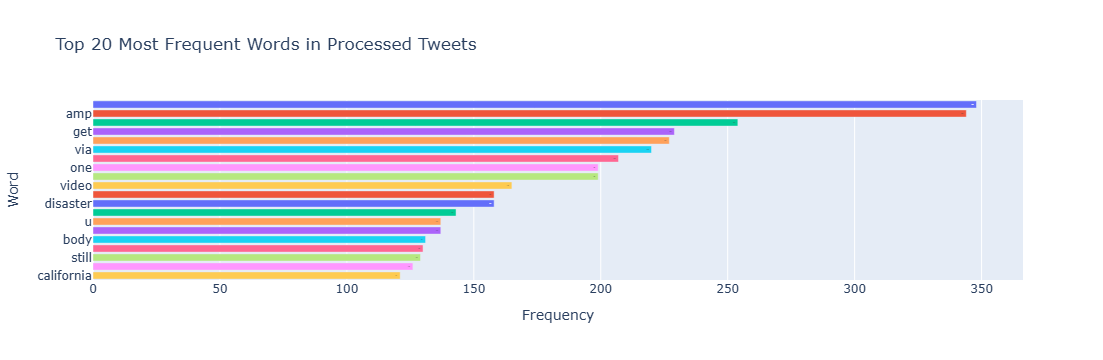

In [39]:
fig = px.bar(top_all_words, x = "Frequency", y = "Word", color = "Word", text = "Frequency", orientation = "h",
             title="Top 20 Most Frequent Words in Processed Tweets")

fig.update_layout(xaxis_title = "Frequency", yaxis_title = "Word", showlegend = False, yaxis = {"categoryorder": "total ascending"})

fig.show()

* **like** is the most frequent word with **348** occurrences followed closely by **amp** with **344** occurrences.
    
* Disaster-related terms such as **fire, disaster, emergency** and **police** also appear frequently in the processed tweets.

## Most Frequent Words in Disaster Tweets

In [40]:
# Combine processed disaster tweets
disaster_text = " ".join(df.loc[df["target"] == 1, "processed_text"])

# Count word frequencies
disaster_word_counts = Counter(disaster_text.split())

# Top 20 disaster words
top_disaster_words = pd.DataFrame(disaster_word_counts.most_common(20),columns = ["Word", "Frequency"])

top_disaster_words

,Word,Frequency
0,fire,182
1,news,146
2,amp,135
3,disaster,121
4,via,121
5,california,115
6,suicide,112
7,police,109
8,people,105
9,killed,95


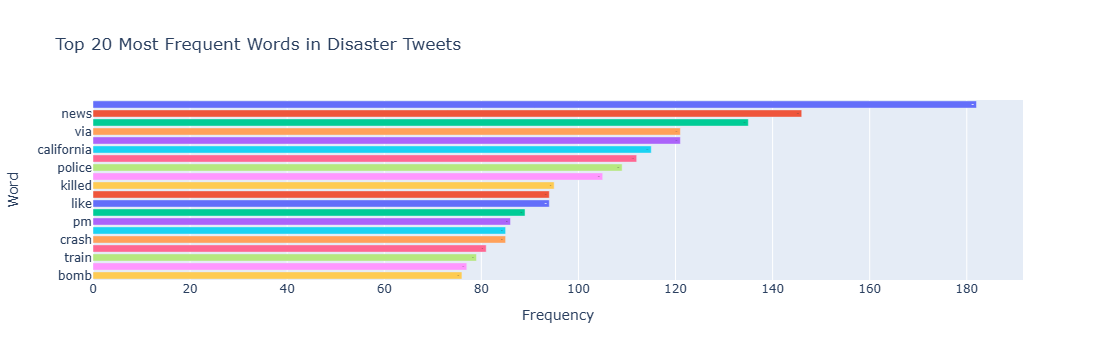

In [41]:
fig = px.bar(top_disaster_words, x = "Frequency", y = "Word", color = "Word", text = "Frequency", orientation = "h",
             title="Top 20 Most Frequent Words in Disaster Tweets")

fig.update_layout(xaxis_title = "Frequency", yaxis_title = "Word", showlegend = False, yaxis = {"categoryorder": "total ascending"})

fig.show()

* **fire** is the most frequent word in disaster tweets with **182** occurrences followed by **news** with **146** occurrences.
    
* Disaster-specific terms such as **disaster, suicide, killed, storm, crash, emergency** and **bomb** appear prominently.


## Most Frequent Words in Non-Disaster Tweets

In [42]:
# Combine processed non-disaster tweets
non_disaster_text = " ".join(df.loc[df["target"] == 0, "processed_text"])

# Count word frequencies
non_disaster_word_counts = Counter(non_disaster_text.split())

# Top 20 non-disaster words
top_non_disaster_words = pd.DataFrame(non_disaster_word_counts.most_common(20), columns = ["Word", "Frequency"])

top_non_disaster_words

,Word,Frequency
0,like,254
1,amp,209
2,new,171
3,get,163
4,one,133
5,body,116
6,would,101
7,via,99
8,video,96
9,people,94


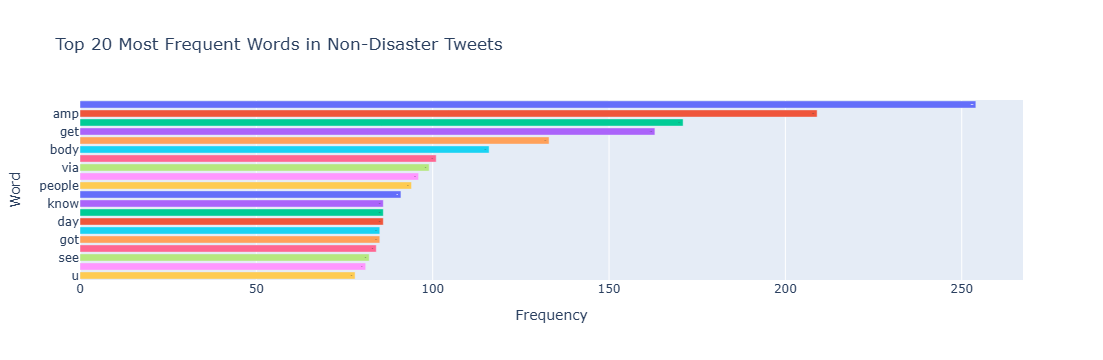

In [43]:
fig = px.bar(top_non_disaster_words, x = "Frequency", y = "Word", color = "Word", text = "Frequency", orientation = "h",
             title="Top 20 Most Frequent Words in Non-Disaster Tweets")

fig.update_layout(xaxis_title = "Frequency", yaxis_title = "Word", showlegend = False, yaxis = {"categoryorder": "total ascending"})

fig.show()

* **like** is the most frequent word in non-disaster tweets with **254** occurrences followed by **amp** with **209** occurrences and **new** with **171** occurrences.
    
* General conversational words such as **love, day, time, know, got** and **see** appear frequently in the non-disaster class.

# Text Feature Extraction

## Bag of Words

### Create Bag-of-Words Representation

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)

# Transform processed tweets into numerical features
X_bow = bow_vectorizer.fit_transform(df["processed_text"])

print("Bag-of-Words Matrix Shape:", X_bow.shape)
print("Vocabulary Size:", len(bow_vectorizer.get_feature_names_out()))

Bag-of-Words Matrix Shape: (7611, 5000)
Vocabulary Size: 5000


* The Bag-of-Words representation contains **7,611** tweets and **5,000** selected text features**.

* The vocabulary size is limited to **5,000** words which helps control dimensionality while preserving important terms.

### View Sample BoW Features

In [45]:
# Display a sample
bow_features = bow_vectorizer.get_feature_names_out()

print("First 20 BoW Features:")
print(bow_features[:20])

First 20 BoW Features:
['aa' 'aba' 'abandon' 'abandoned' 'abbott' 'abbswinston' 'abc' 'abcnews'
 'abe' 'abia' 'ability' 'ablaze' 'able' 'abomination' 'abortion'
 'absolute' 'absolutely' 'abstorm' 'abuse' 'abused']


* The Bag-of-Words vocabulary contains valid terms extracted from the processed tweets such as **abandon, abandoned, ablaze** and **abuse**.

* Different word forms are treated as separate features which is expected in the current Bag-of-Words representation.

## TF-IDF Vectorization

### Create TF IDF Representation

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Transform processed tweets into TF IDF features
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print("TF-IDF Matrix Shape:", X_tfidf.shape)
print("Vocabulary Size:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF Matrix Shape: (7611, 5000)
Vocabulary Size: 5000


* The TF-IDF representation contains **7,611** tweets and **5,000** selected text features.

* A vocabulary of **5,000** terms has been retained to provide a manageable numerical representation of the tweet text.

### View Sample TF-IDF Features

In [47]:
# Display a sample
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("First 20 TF-IDF Features:")
print(tfidf_features[:20])

First 20 TF-IDF Features:
['aa' 'aba' 'abandon' 'abandoned' 'abbott' 'abbswinston' 'abc' 'abcnews'
 'abe' 'abia' 'ability' 'ablaze' 'able' 'abomination' 'abortion'
 'absolute' 'absolutely' 'abstorm' 'abuse' 'abused']


* The TF-IDF vocabulary successfully contains terms extracted from the processed tweet text.

* The feature names are similar to Bag of Words because both methods use the same processed textual data.

### Non-Zero TF IDF Features for a Sample Tweet

In [48]:
# Display non-zero TF IDF features
first_tweet_vector = X_tfidf[0].toarray().flatten()

non_zero_indices = first_tweet_vector.nonzero()[0]

tfidf_example = pd.DataFrame({"Word": tfidf_features[non_zero_indices], "TF-IDF Score": first_tweet_vector[non_zero_indices]}).sort_values(by="TF-IDF Score", ascending = False).round(3)

tfidf_example

,Word,TF-IDF Score
0,allah,0.540
3,reason,0.488
1,earthquake,0.434
2,may,0.387
4,us,0.364


* **allah** receives the highest TF-IDF score of **0.540** followed by **reason** **0.488** and **earthquake** **0.434**.

* The different TF IDF scores show that words are assigned varying importance within the tweet rather than simple occurrence counts.

# Sentiment Analysis & Additional Feature Engineering

## Initialize Sentiment Analyzer

In [49]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

## Generate Sentiment Scores

In [50]:
# Generate sentiment scores
sentiment_scores = df["text"].apply(sia.polarity_scores)

df["negative_score"] = sentiment_scores.apply(lambda x: x["neg"])
df["neutral_score"] = sentiment_scores.apply(lambda x: x["neu"])
df["positive_score"] = sentiment_scores.apply(lambda x: x["pos"])
df["compound_score"] = sentiment_scores.apply(lambda x: x["compound"])

df[["text", "negative_score", "neutral_score", "positive_score", "compound_score"]].head()

,text,negative_score,neutral_score,positive_score,compound_score
0,Our Deeds are the Reason of this #earthquake M...,0.000,0.851,0.149,0.2732
1,Forest fire near La Ronge Sask. Canada,0.286,0.714,0.000,-0.3400
2,All residents asked to 'shelter in place' are ...,0.095,0.905,0.000,-0.2960
3,"13,000 people receive #wildfires evacuation or...",0.000,1.000,0.000,0.0000
4,Just got sent this photo from Ruby #Alaska as ...,0.000,1.000,0.000,0.0000


* The first tweet shows a positive compound sentiment score of **0.2732** while the second and third tweets show negative scores of **-0.3400** and **-0.2960**.

* The fourth and fifth tweets receive a **0.0000** compound score indicating neutral sentiment according to VADER.

## Create Sentiment Category

In [51]:
def get_sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["compound_score"].apply(get_sentiment_label)

df[["text", "compound_score", "sentiment"]].head()

,text,compound_score,sentiment
0,Our Deeds are the Reason of this #earthquake M...,0.2732,Positive
1,Forest fire near La Ronge Sask. Canada,-0.3400,Negative
2,All residents asked to 'shelter in place' are ...,-0.2960,Negative
3,"13,000 people receive #wildfires evacuation or...",0.0000,Neutral
4,Just got sent this photo from Ruby #Alaska as ...,0.0000,Neutral


* The compound sentiment scores were successfully converted into **Positive, Negative** and **Neutral** sentiment categories.

* In the displayed sample, the first tweet is classified as Positive the next two as Negative and the last two as Neutral.

## Sentiment Distribution

In [52]:
sentiment_distribution = (df["sentiment"].value_counts().reset_index())

sentiment_distribution.columns = ["Sentiment", "Count"]

sentiment_distribution

,Sentiment,Count
0,Negative,3707
1,Neutral,2011
2,Positive,1893


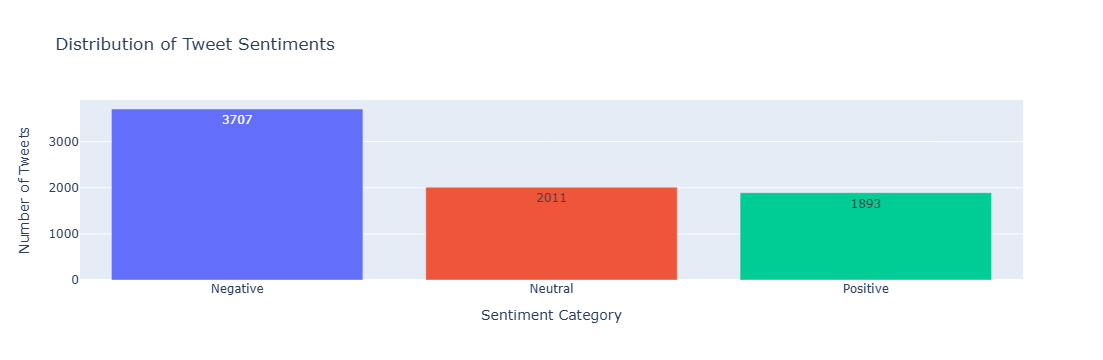

In [53]:
fig = px.bar(sentiment_distribution, x = "Sentiment", y = "Count", color = "Sentiment", text = "Count", title = "Distribution of Tweet Sentiments")

fig.update_layout(xaxis_title = "Sentiment Category", yaxis_title = "Number of Tweets", showlegend = False)

fig.show()

* Negative sentiment is the most common category with **3,707** tweets representing the largest portion of the dataset.

* Neutral sentiment accounts for **2,011** tweets while Positive sentiment is the least frequent with **1,893** tweets.

## Sentiment vs Disaster Category

In [54]:
sentiment_target = (df.groupby(["sentiment", "target"]).size().reset_index(name="Count"))

sentiment_target["Category"] = sentiment_target["target"].map({0: "Non-Disaster", 1: "Disaster"})

sentiment_target

,sentiment,target,Count,Category
0,Negative,0,1846,Non-Disaster
1,Negative,1,1861,Disaster
2,Neutral,0,1132,Non-Disaster
3,Neutral,1,879,Disaster
4,Positive,0,1363,Non-Disaster
5,Positive,1,530,Disaster


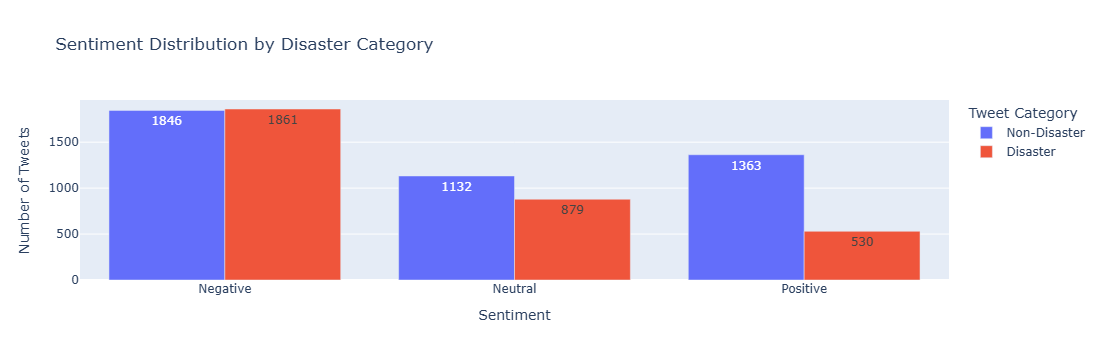

In [55]:
fig = px.bar(sentiment_target, x = "sentiment", y = "Count", color = "Category", barmode = "group", text = "Count",
             title = "Sentiment Distribution by Disaster Category", labels={"sentiment": "Sentiment", "Count": "Number of Tweets",
                                                                            "Category": "Tweet Category"})

fig.show()

* Negative sentiment is almost equally distributed with **1,861 disaster** tweets and **1,846 non-disaster** tweets.

* Positive sentiment is much more common in non-disaster tweets **1,363** than in disaster tweets **530**.

# Train-Test Split & Final Feature Preparation

## Define Input and Target Variables

In [56]:
X = df["processed_text"]
y = df["target"]

print("Input Records:", X.shape[0])
print("Target Records:", y.shape[0])

Input Records: 7611
Target Records: 7611


## Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

print("Training Text Shape:", X_train_text.shape)
print("Testing Text Shape:", X_test_text.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Text Shape: (6088,)
Testing Text Shape: (1523,)
Training Target Shape: (6088,)
Testing Target Shape: (1523,)


* The dataset has been successfully divided into **6,088 training records** and **1,523 testing records**.

* The target arrays have matching shapes confirming that the input text and labels are properly aligned.

## Check Class Distribution After Split

In [58]:
train_distribution = y_train.value_counts().sort_index()
test_distribution = y_test.value_counts().sort_index()

distribution_df = pd.DataFrame({"Training": train_distribution,"Testing": test_distribution})

distribution_df.index = ["Non-Disaster", "Disaster"]

distribution_df

,Training,Testing
Non-Disaster,3472,869
Disaster,2616,654


* The training set contains **3,472 non-disaster** and **2,616 disaster tweets**, while the test set contains **869 non-disaster** and **654 disaster tweets**.

* Both training and testing sets maintain a similar class distribution due to the stratified split.

## Final TF IDF Transformation

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

final_tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = final_tfidf.fit_transform(X_train_text)

X_test_tfidf = final_tfidf.transform(X_test_text)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)
print("Final Vocabulary Size:", len(final_tfidf.get_feature_names_out()))

Training TF-IDF Shape: (6088, 5000)
Testing TF-IDF Shape: (1523, 5000)
Final Vocabulary Size: 5000


* The training and testing text have been successfully transformed into TF-IDF matrices with **5,000 features**.

* The training matrix contains **6,088 tweets** while the testing matrix contains **1,523 tweets** matching the train-test split.

# Model Selection & Training

## Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report)

logistic_model = LogisticRegression(max_iter=1000,random_state=42)

logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Logistic Regression Performance

In [61]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-Score  : {logistic_f1:.4f}")

Accuracy  : 0.8273
Precision : 0.8485
Recall    : 0.7278
F1-Score  : 0.7835


* Logistic Regression achieved an **accuracy of 82.73%** showing strong overall classification performance.

* The model achieved **84.85% precision** indicating that most tweets predicted as disasters were actually disaster-related.

### Logistic Regression Classification Report

In [62]:
print("Classification Report - Logistic Regression\n")

print(classification_report(y_test, logistic_predictions, target_names=["Non-Disaster", "Disaster"]))

Classification Report - Logistic Regression

              precision    recall  f1-score   support

Non-Disaster       0.81      0.90      0.86       869
    Disaster       0.85      0.73      0.78       654

    accuracy                           0.83      1523
   macro avg       0.83      0.82      0.82      1523
weighted avg       0.83      0.83      0.83      1523



* The model performs better on **Non-Disaster tweets** achieving a recall of **90%** and an F1-score of **86%**.

* For **Disaster tweets** precision is strong at **85%** but recall is comparatively lower at **73%** indicating that some actual disaster tweets are missed.

## Random Forest Classifier

In [63]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1)

random_forest_model.fit(X_train_tfidf, y_train)

rf_predictions = random_forest_model.predict(X_test_tfidf)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Performance

In [64]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

Accuracy  : 0.7978
Precision : 0.7952
Recall    : 0.7125
F1-Score  : 0.7516


* Random Forest achieved an overall accuracy of **79.78%** showing reasonably good classification performance.

* The model obtained **79.52% precision** and **71.25% recall** indicating that some actual disaster tweets are still missed.

### Random Forest Classification Report

In [65]:
print("Classification Report - Random Forest\n")

print(classification_report(y_test, rf_predictions, target_names = ["Non-Disaster", "Disaster"]))

Classification Report - Random Forest

              precision    recall  f1-score   support

Non-Disaster       0.80      0.86      0.83       869
    Disaster       0.80      0.71      0.75       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



* Random Forest performs better on **Non-Disaster tweets** achieving **86% recall** and an **83% F1-score**.

* For **Disaster tweets** the model achieves **80% precision** but recall decreases to **71%** indicating that some actual disaster tweets are not detected.

## Multinomial Naive Bayes

In [66]:
from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

nb_predictions = naive_bayes_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


### Multinomial Naive Bayes Performance

In [67]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

Accuracy  : 0.8122
Precision : 0.8407
Recall    : 0.6942
F1-Score  : 0.7605


* Multinomial Naive Bayes achieved an overall accuracy of **81.22%** with a strong precision of **84.07%**.

* The recall is comparatively lower at **69.42%** indicating that the model misses a noticeable portion of actual disaster tweets.

### Multinomial Naive Bayes Classification Report

In [68]:
print("Classification Report - Multinomial Naive Bayes\n")

print(classification_report(y_test, nb_predictions, target_names = ["Non-Disaster", "Disaster"]))

Classification Report - Multinomial Naive Bayes

              precision    recall  f1-score   support

Non-Disaster       0.80      0.90      0.85       869
    Disaster       0.84      0.69      0.76       654

    accuracy                           0.81      1523
   macro avg       0.82      0.80      0.80      1523
weighted avg       0.82      0.81      0.81      1523



* The model performs better on **Non-Disaster tweets** achieving **90% recall** and an **85% F1-score**.

* For **Disaster tweets**, precision is strong at **84%** but recall drops to **69%** showing that some actual disaster tweets are missed.

# Initial Model Comparison

## Create Model Comparison Table

In [69]:
model_comparison = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "Multinomial Naive Bayes"],
                                 "Accuracy": [logistic_accuracy, rf_accuracy, nb_accuracy],
                                 "Precision": [logistic_precision, rf_precision, nb_precision],
                                 "Recall": [logistic_recall, rf_recall, nb_recall],
                                 "F1-Score": [logistic_f1, rf_f1, nb_f1]})

# Convert metrics into percentages
comparison_display = model_comparison.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:comparison_display[column] = (comparison_display[column] * 100).round(2)

comparison_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,82.73,84.85,72.78,78.35
1,Random Forest,79.78,79.52,71.25,75.16
2,Multinomial Naive Bayes,81.22,84.07,69.42,76.05


* Logistic Regression achieved the highest **Accuracy 82.73%** and **F1-Score 78.35%** among the three initial models.

* Logistic Regression also produced the highest **Precision 84.85%** and **Recall 72.78%** while Multinomial Naive Bayes remained relatively close in precision at **84.07%**.

## Model Performance Comparison Chart

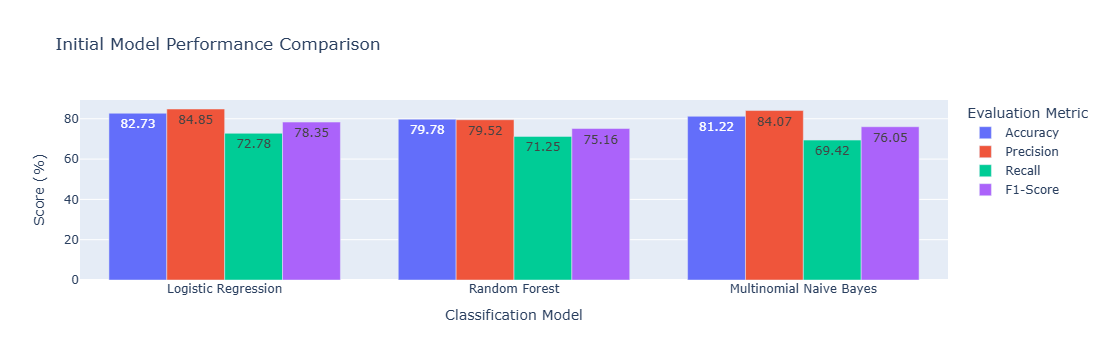

In [70]:
comparison_plot = model_comparison.melt(id_vars = "Model", var_name = "Metric", value_name = "Score")

comparison_plot["Score"] = comparison_plot["Score"] * 100

fig = px.bar(comparison_plot, x = "Model", y = "Score", color = "Metric", barmode = "group", text_auto = ".2f",
             title="Initial Model Performance Comparison")

fig.update_layout(xaxis_title = "Classification Model", yaxis_title = "Score (%)", legend_title = "Evaluation Metric")

fig.show()

* Logistic Regression shows the strongest overall performance across all four evaluation metrics.

* Multinomial Naive Bayes performs close to Logistic Regression in precision while its recall is comparatively lower.

### Rank Models by F1-Score

In [71]:
model_ranking = model_comparison[["Model", "F1-Score"]].sort_values(by = "F1-Score", ascending = False).reset_index(drop=True)

model_ranking["F1-Score"] = (model_ranking["F1-Score"] * 100).round(2)

model_ranking.index = model_ranking.index + 1

model_ranking

,Model,F1-Score
1,Logistic Regression,78.35
2,Multinomial Naive Bayes,76.05
3,Random Forest,75.16


* Logistic Regression ranks first with the highest **F1-Score of 78.35%**.

* Multinomial Naive Bayes follows with **76.05%** while Random Forest records **75.16%**.

# Cross-Validation

## Define Stratified 5 Fold Cross-Validation

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

stratified_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

print("Stratified 5-Fold Cross-Validation initialized successfully.")

Stratified 5-Fold Cross-Validation initialized successfully.


## Logistic Regression Cross-Validation

In [73]:
logistic_cv_scores = cross_val_score(logistic_model, X_train_tfidf, y_train, cv = stratified_cv, scoring="f1")

print("Logistic Regression F1-Scores:")
print(logistic_cv_scores)

print("\nMean F1-Score:", round(logistic_cv_scores.mean(), 4))
print("Standard Deviation:", round(logistic_cv_scores.std(), 4))

Logistic Regression F1-Scores:
[0.74279616 0.71734475 0.71914894 0.74273412 0.73684211]

Mean F1-Score: 0.7318
Standard Deviation: 0.0113


* Logistic Regression achieved a mean cross validation **F1-Score of 73.18%** across the five folds.

* The low standard deviation of **1.13%** indicates relatively consistent performance across different training-validation splits.

## Random Forest Cross-Validation

In [74]:
rf_cv_scores = cross_val_score(random_forest_model, X_train_tfidf, y_train, cv = stratified_cv, scoring = "f1", n_jobs = -1)

print("Random Forest F1-Scores:")
print(rf_cv_scores)

print("\nMean F1-Score:", round(rf_cv_scores.mean(), 4))
print("Standard Deviation:", round(rf_cv_scores.std(), 4))

Random Forest F1-Scores:
[0.74743326 0.70366492 0.700611   0.73560768 0.73368984]

Mean F1-Score: 0.7242
Standard Deviation: 0.0186


* Random Forest achieved a mean cross-validation **F1-Score of 72.42%** across the five folds.

* The standard deviation of **1.86%** indicates some variation across folds but the model performance remains reasonably consistent.

## Multinomial Naive Bayes Cross-Validation

In [75]:
nb_cv_scores = cross_val_score(naive_bayes_model, X_train_tfidf, y_train, cv = stratified_cv, scoring = "f1", n_jobs = -1)

print("Multinomial Naive Bayes F1-Scores:")
print(nb_cv_scores)

print("\nMean F1-Score:", round(nb_cv_scores.mean(), 4))
print("Standard Deviation:", round(nb_cv_scores.std(), 4))

Multinomial Naive Bayes F1-Scores:
[0.75       0.7212766  0.70981211 0.74097665 0.74867444]

Mean F1-Score: 0.7341
Standard Deviation: 0.0159


* Multinomial Naive Bayes achieved a mean cross-validation **F1-Score of 73.41%** across the five folds.

* The standard deviation of **1.59%** indicates reasonably stable performance across different validation splits.

## Cross-Validation Model Comparison

In [76]:
cv_comparison = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "Multinomial Naive Bayes"],
                              "Mean F1-Score": [logistic_cv_scores.mean(), rf_cv_scores.mean(), nb_cv_scores.mean()],
                              "Standard Deviation": [logistic_cv_scores.std(), rf_cv_scores.std(), nb_cv_scores.std()]})

cv_display = cv_comparison.copy()

cv_display["Mean F1-Score"] = (cv_display["Mean F1-Score"] * 100).round(2)

cv_display["Standard Deviation"] = (cv_display["Standard Deviation"] * 100).round(2)

cv_display

,Model,Mean F1-Score,Standard Deviation
0,Logistic Regression,73.18,1.13
1,Random Forest,72.42,1.86
2,Multinomial Naive Bayes,73.41,1.59


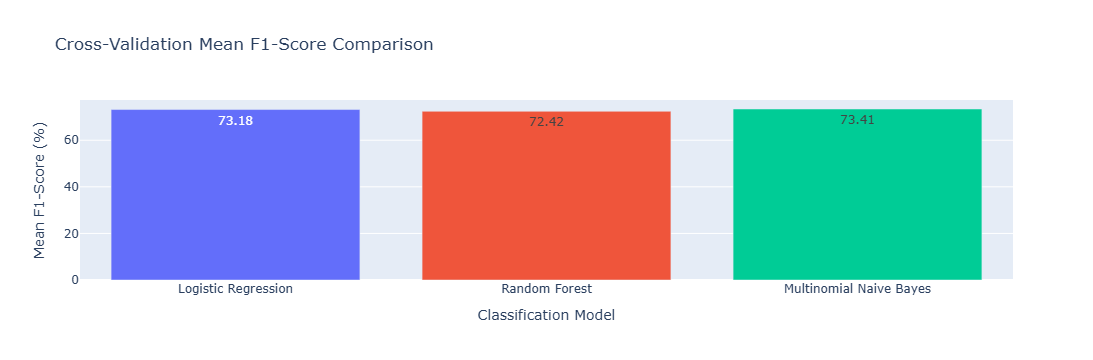

In [77]:
fig = px.bar(cv_display, x = "Model", y = "Mean F1-Score", color = "Model", text = "Mean F1-Score",
             title="Cross-Validation Mean F1-Score Comparison")

fig.update_layout(xaxis_title = "Classification Model", yaxis_title = "Mean F1-Score (%)", showlegend = False)

fig.show()

* Multinomial Naive Bayes achieved the highest cross-validation mean F1-score of **73.41%** closely followed by Logistic Regression at **73.18%**.

* Logistic Regression recorded the lowest standard deviation of **1.13%** indicating the most consistent performance across the five folds.

# Hyperparameter Tuning

## Logistic Regression Hyperparameter Tuning

In [78]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10], "solver": ["liblinear", "lbfgs"], "class_weight": [None, "balanced"]}

# Initialize GridSearchCV
logistic_grid = GridSearchCV(estimator = LogisticRegression(max_iter = 1000, random_state = 42), param_grid = logistic_param_grid, scoring = "f1",
                             cv = stratified_cv, n_jobs = -1)

# Perform hyperparameter tuning
logistic_grid.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(logistic_grid.best_score_, 4))

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best Cross-Validation F1-Score:
0.7497


* Hyperparameter tuning improved the Logistic Regression cross-validation F1-score from **73.18% to 74.97%**.

* The best configuration used **C = 1**, **class_weight = balanced** and the **lbfgs solver**.

## Tuned Logistic Regression Test Performance

In [79]:
# Get the best Logistic Regression model
tuned_logistic_model = logistic_grid.best_estimator_

# Generate predictions on the test set
tuned_logistic_predictions = tuned_logistic_model.predict(X_test_tfidf)

# Calculate evaluation metrics
tuned_logistic_accuracy = accuracy_score(y_test, tuned_logistic_predictions)

tuned_logistic_precision = precision_score(y_test, tuned_logistic_predictions)

tuned_logistic_recall = recall_score(y_test, tuned_logistic_predictions)

tuned_logistic_f1 = f1_score(y_test, tuned_logistic_predictions)

print(f"Accuracy  : {tuned_logistic_accuracy:.4f}")
print(f"Precision : {tuned_logistic_precision:.4f}")
print(f"Recall    : {tuned_logistic_recall:.4f}")
print(f"F1-Score  : {tuned_logistic_f1:.4f}")

Accuracy  : 0.8089
Precision : 0.7746
Recall    : 0.7829
F1-Score  : 0.7787


* After tuning, the disaster-class recall improved from **72.78% to 78.29%** indicating better detection of actual disaster tweets.

* Accuracy and precision decreased to **80.89%** and **77.46%** while the F1-score remained close to the original model at **77.87%**.

## Multinomial Naive Bayes Hyperparameter Tuning

In [80]:
nb_param_grid = {"alpha": [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]}

# Initialize GridSearchCV
nb_grid = GridSearchCV(estimator = MultinomialNB(), param_grid = nb_param_grid, scoring = "f1", cv = stratified_cv, n_jobs = -1)

# Perform hyperparameter tuning
nb_grid.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(nb_grid.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(nb_grid.best_score_, 4))

Best Parameters:
{'alpha': 0.75}

Best Cross-Validation F1-Score:
0.7388


* Hyperparameter tuning selected **alpha = 0.75** as the best configuration for Multinomial Naive Bayes.

* The cross-validation F1-score improved from **73.41% to 73.88%** after tuning.

## Tuned Multinomial Naive Bayes Test Performance

In [81]:
# Get the best Multinomial Naive Bayes model
tuned_nb_model = nb_grid.best_estimator_

# Generate predictions on the test set
tuned_nb_predictions = tuned_nb_model.predict(X_test_tfidf)

# Calculate evaluation metrics
tuned_nb_accuracy = accuracy_score(y_test, tuned_nb_predictions)

tuned_nb_precision = precision_score(y_test, tuned_nb_predictions)

tuned_nb_recall = recall_score(y_test, tuned_nb_predictions)

tuned_nb_f1 = f1_score(y_test, tuned_nb_predictions)

print(f"Accuracy  : {tuned_nb_accuracy:.4f}")
print(f"Precision : {tuned_nb_precision:.4f}")
print(f"Recall    : {tuned_nb_recall:.4f}")
print(f"F1-Score  : {tuned_nb_f1:.4f}")

Accuracy  : 0.8142
Precision : 0.8404
Recall    : 0.7003
F1-Score  : 0.7640


* The tuned Multinomial Naive Bayes model achieved an accuracy of **81.42%** and an F1-score of **76.40%**.

* Recall improved from **69.42% to 70.03%** while precision remained almost unchanged at approximately **84%**.

## Original vs Tuned Model Comparison

In [82]:
tuning_comparison = pd.DataFrame({"Model": ["Original Logistic Regression", "Tuned Logistic Regression", "Original Naive Bayes", "Tuned Naive Bayes"],
                                  "Accuracy": [logistic_accuracy, tuned_logistic_accuracy, nb_accuracy, tuned_nb_accuracy],
                                  "Precision": [logistic_precision, tuned_logistic_precision, nb_precision, tuned_nb_precision],
                                  "Recall": [logistic_recall, tuned_logistic_recall, nb_recall, tuned_nb_recall],
                                  "F1-Score": [logistic_f1, tuned_logistic_f1, nb_f1, tuned_nb_f1]})

# Convert metrics into percentages
tuning_display = tuning_comparison.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:tuning_display[column] = (tuning_display[column] * 100).round(2)

tuning_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Original Logistic Regression,82.73,84.85,72.78,78.35
1,Tuned Logistic Regression,80.89,77.46,78.29,77.87
2,Original Naive Bayes,81.22,84.07,69.42,76.05
3,Tuned Naive Bayes,81.42,84.04,70.03,76.40


In [83]:
tuning_plot = tuning_comparison.melt(id_vars = "Model", var_name = "Metric", value_name = "Score")

# Convert scores into percentage
tuning_plot["Score"] = tuning_plot["Score"] * 100

fig = px.bar(tuning_plot, x = "Model", y = "Score", color = "Metric", barmode = "group", text_auto = ".2f",
             title = "Original vs Tuned Model Performance")

fig.update_layout(xaxis_title = "Model", yaxis_title = "Score (%)", legend_title = "Evaluation Metric")

fig.show()

* Original Logistic Regression achieved the highest **Accuracy 82.73%** and **F1-Score 78.35%** among the compared configurations.

* Tuning Logistic Regression substantially improved **Recall from 72.78% to 78.29%** although Accuracy and Precision decreased.

# Final Model Evaluation

In [84]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
tuned_logistic_cm = confusion_matrix(y_test, tuned_logistic_predictions)

print("Confusion Matrix - Tuned Logistic Regression")
print(tuned_logistic_cm)

Confusion Matrix - Tuned Logistic Regression
[[720 149]
 [142 512]]


* The model correctly classified **720 non-disaster tweets** and **512 disaster tweets**.

* It produced **149 false positives** and **142 false negatives** showing that both types of classification errors are present.

# ROC Curve and AUC Score

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for Disaster class
tuned_logistic_probabilities = tuned_logistic_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, tuned_logistic_probabilities)

# Calculate AUC score
tuned_logistic_auc = roc_auc_score(y_test, tuned_logistic_probabilities)

print("ROC-AUC Score:", round(tuned_logistic_auc, 4))

ROC-AUC Score: 0.8684


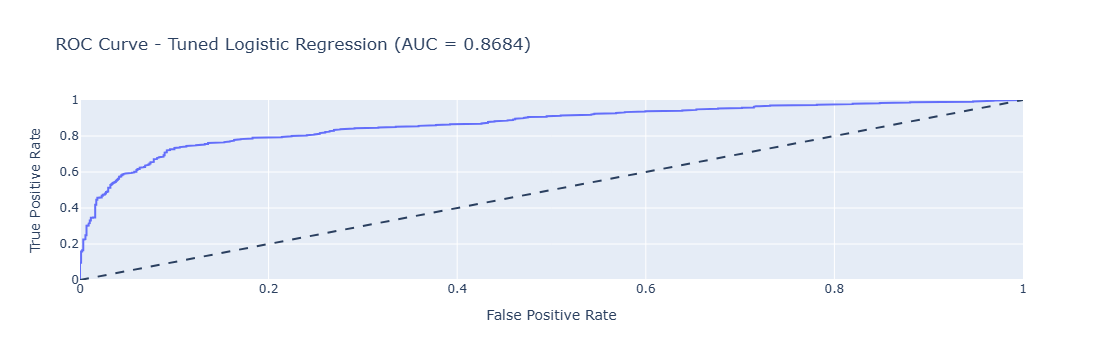

In [86]:
fig = px.line(x = fpr, y = tpr, title = f"ROC Curve - Tuned Logistic Regression (AUC = {tuned_logistic_auc:.4f})",
              labels={"x": "False Positive Rate", "y": "True Positive Rate"})

# Add random classifier reference line
fig.add_shape(type="line", x0 = 0, y0 = 0, x1 = 1, y1 = 1, line = dict(dash = "dash"))

fig.update_layout(xaxis = dict(range=[0, 1]), yaxis = dict(range=[0, 1]))

fig.show()

* The Tuned Logistic Regression model achieved a **ROC-AUC score of 0.8684** indicating strong ability to distinguish between disaster and non-disaster tweets.

* The ROC curve remains well above the random classifier reference line showing effective classification across different probability thresholds.

## Precisio Recall Curve

In [87]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, tuned_logistic_probabilities)

# Calculate Average Precision Score
average_precision = average_precision_score(y_test,tuned_logistic_probabilities)

print("Average Precision Score:", round(average_precision, 4))

Average Precision Score: 0.8616


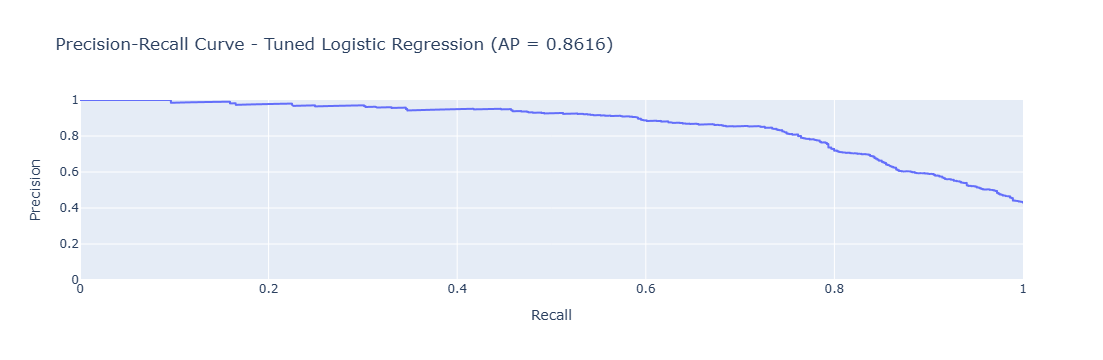

In [88]:
fig = px.line(x = recall_values, y = precision_values, title = f"Precision-Recall Curve - Tuned Logistic Regression (AP = {average_precision:.4f})",
              labels={"x": "Recall", "y": "Precision"})

fig.update_layout(xaxis = dict(range = [0, 1]), yaxis = dict(range = [0, 1]))

fig.show()

* The Tuned Logistic Regression model achieved an **Average Precision Score of 0.8616** indicating strong performance in identifying disaster tweets.

* The Precision-Recall curve maintains relatively high precision across a broad range of recall values.

## Final Classification Report

In [89]:
print("Final Classification Report - Tuned Logistic Regression\n")

print(classification_report(y_test, tuned_logistic_predictions, target_names = ["Non-Disaster", "Disaster"]))

Final Classification Report - Tuned Logistic Regression

              precision    recall  f1-score   support

Non-Disaster       0.84      0.83      0.83       869
    Disaster       0.77      0.78      0.78       654

    accuracy                           0.81      1523
   macro avg       0.80      0.81      0.81      1523
weighted avg       0.81      0.81      0.81      1523



* The tuned Logistic Regression model achieved an overall **accuracy of 81%** on the test dataset.

* For Disaster tweets, the model achieved **77% precision, 78% recall, and 78% F1-score** showing a balanced ability to identify disaster-related tweets.

## Final Evaluation Metrics Summary

In [90]:
final_metrics = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Average Precision"],
                              "Score": [tuned_logistic_accuracy, tuned_logistic_precision, tuned_logistic_recall, tuned_logistic_f1,
                                        tuned_logistic_auc, average_precision]})

# Convert scores into percentages
final_metrics["Score (%)"] = (final_metrics["Score"] * 100).round(2)

final_metrics = final_metrics[["Metric", "Score (%)"]]

final_metrics

,Metric,Score (%)
0,Accuracy,80.89
1,Precision,77.46
2,Recall,78.29
3,F1-Score,77.87
4,ROC-AUC,86.84
5,Average Precision,86.16


* The Tuned Logistic Regression model achieved balanced classification performance with **80.89% accuracy** and an **F1-Score of 77.87%**.

* A **Recall of 78.29%** indicates that the model successfully identifies a substantial proportion of actual disaster tweets.

# Final Model Selection

## Original vs Tuned Logistic Regression

In [91]:
# Compare Original and Tuned Logistic Regression
final_model_comparison = pd.DataFrame({"Model": ["Original Logistic Regression", "Tuned Logistic Regression"],
                                       "Accuracy": [logistic_accuracy, tuned_logistic_accuracy],
                                       "Precision": [logistic_precision, tuned_logistic_precision],
                                       "Recall": [logistic_recall, tuned_logistic_recall],
                                       "F1-Score": [logistic_f1, tuned_logistic_f1]})

# Convert metrics into percentages
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    final_model_comparison[column] = (final_model_comparison[column] * 100).round(2)

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Original Logistic Regression,82.73,84.85,72.78,78.35
1,Tuned Logistic Regression,80.89,77.46,78.29,77.87


## Calculate Change After Tuning

In [92]:
performance_change = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
                                   "Change (Percentage Points)": [(tuned_logistic_accuracy - logistic_accuracy) * 100,
                                                                  (tuned_logistic_precision - logistic_precision) * 100,
                                                                  (tuned_logistic_recall - logistic_recall) * 100,
                                                                  (tuned_logistic_f1 - logistic_f1) * 100]})

performance_change["Change (Percentage Points)"] = (performance_change["Change (Percentage Points)"].round(2))

performance_change

,Metric,Change (Percentage Points)
0,Accuracy,-1.84
1,Precision,-7.39
2,Recall,5.50
3,F1-Score,-0.48


* Hyperparameter tuning increased Disaster-class Recall by **5.50 percentage points** improving the detection of actual disaster tweets.

* Accuracy decreased by **1.84 points** and Precision by **7.39 points** showing a trade-off for the improved Recall.

## Final Model Decision

* The **Tuned Logistic Regression** model is selected as the final model.

* Although the original Logistic Regression achieved a slightly higher F1-Score tuning increased Disaster-class Recall from **72.78% to 78.29%**. 
    
* This represents a substantial improvement in the model's ability to identify actual disaster tweets.

# Prediction on New Tweets

## Create Prediction Function

In [93]:
# Function to preprocess and predict a new tweet
def predict_tweet(tweet):
    
    # Clean the text
    cleaned = clean_text(tweet)
    
    # Tokenize
    tokens = cleaned.split()
    
    # Remove stop words
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words]
    
    # Rejoin processed text
    processed = " ".join(filtered_tokens)
    
    # Convert text using fitted TF IDF vectorizer
    tweet_vector = final_tfidf.transform([processed])
    
    # Predict class and probability
    prediction = tuned_logistic_model.predict(tweet_vector)[0]
    probability = tuned_logistic_model.predict_proba(tweet_vector)[0]
    
    label = "Disaster" if prediction == 1 else "Non-Disaster"
    confidence = probability[prediction] * 100
    
    return label, round(confidence, 2)

## Test the Function on Sample Tweets

In [94]:
sample_tweets = ["Massive earthquake reported near the city, several buildings have collapsed.",
                 "Had an amazing day at the beach with my friends!",
                 "Emergency crews are responding to a large wildfire spreading near residential areas.",
                 "This movie was absolutely fire, I loved every scene."]

for tweet in sample_tweets:
    prediction, confidence = predict_tweet(tweet)
    
    print("Tweet      :", tweet)
    print("Prediction :", prediction)
    print("Confidence :", f"{confidence}%")
    print("-" * 70)

Tweet      : Massive earthquake reported near the city, several buildings have collapsed.
Prediction : Disaster
Confidence : 95.13%
----------------------------------------------------------------------
Tweet      : Had an amazing day at the beach with my friends!
Prediction : Non-Disaster
Confidence : 79.72%
----------------------------------------------------------------------
Tweet      : Emergency crews are responding to a large wildfire spreading near residential areas.
Prediction : Disaster
Confidence : 89.81%
----------------------------------------------------------------------
Tweet      : This movie was absolutely fire, I loved every scene.
Prediction : Disaster
Confidence : 51.79%
----------------------------------------------------------------------


* The model correctly identified clear disaster-related tweets about an earthquake and wildfire with high confidence scores of **95.13%** and **89.81%**.

* It also correctly classified the normal beach-related tweet as **Non-Disaster** with **79.72% confidence** showing good performance on clearly non-disaster content.

# Save Final Model & TF IDF Vectorizer

In [95]:
import joblib

joblib.dump(tuned_logistic_model,"disaster_tweet_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


## Save the TF IDF Vectorizer

In [96]:
joblib.dump(final_tfidf,"tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


## Verify Saved Files

In [97]:
import os

saved_files = ["disaster_tweet_model.pkl","tfidf_vectorizer.pkl"]

for file in saved_files:
    if os.path.exists(file):
        print(f"{file} saved successfully.")
    else:
        print(f"{file} not found.")

disaster_tweet_model.pkl saved successfully.
tfidf_vectorizer.pkl saved successfully.


* The final tuned Logistic Regression model and TF-IDF vectorizer were successfully saved as **.pkl** files.

* Saving both components ensures that the same trained model and text transformation can be reused during deployment.

# Deployment Preparation

## Load Saved Model and Vectorizer

In [98]:
loaded_model = joblib.load("disaster_tweet_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Saved model and vectorizer loaded successfully.")

Saved model and vectorizer loaded successfully.


## Create Deployment Prediction Function

In [99]:
def deployment_predict(tweet):
    
    # Clean text
    cleaned_text = clean_text(tweet)
    
    # Tokenize
    tokens = cleaned_text.split()
    
    # Remove stop words
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words]
    
    # Create processed text
    processed_text = " ".join(filtered_tokens)
    
    # Transform using saved TF IDF vector
    vectorized_text = loaded_vectorizer.transform([processed_text])
    
    # Generate prediction and probability
    prediction = loaded_model.predict(vectorized_text)[0]
    
    probabilities = loaded_model.predict_proba(vectorized_text)[0]
    
    label = ("Disaster"
        if prediction == 1
        else "Non-Disaster")
    
    confidence = probabilities[prediction] * 100
    
    return label, round(confidence, 2)

## Test Loaded Deployment Pipeline

In [100]:
test_tweet = ("A major earthquake has damaged several buildings " "and emergency teams are responding.")

prediction, confidence = deployment_predict(test_tweet)

print("Tweet      :", test_tweet)
print("Prediction :", prediction)
print("Confidence :", f"{confidence}%")

Tweet      : A major earthquake has damaged several buildings and emergency teams are responding.
Prediction : Disaster
Confidence : 87.19%


* The saved model and TF-IDF vectorizer were successfully reloaded and used for prediction.

* The test tweet was correctly classified as **Disaster** with **87.19% confidence**.

# Web Application Development

## Create Flask Application File

In [101]:
app_code = r'''
from flask import Flask, render_template, request
import joblib
import re
import nltk
from nltk.corpus import stopwords

app = Flask(__name__)

# Load saved model and vectorizer
model = joblib.load("disaster_tweet_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words]
    return " ".join(filtered_tokens)


@app.route("/", methods=["GET", "POST"])
def home():
    prediction = None
    confidence = None
    tweet = ""

    if request.method == "POST":
        tweet = request.form["tweet"]

        processed_text = preprocess_text(tweet)
        vectorized_text = vectorizer.transform([processed_text])

        predicted_class = model.predict(vectorized_text)[0]
        probabilities = model.predict_proba(vectorized_text)[0]

        prediction = (
            "Disaster"
            if predicted_class == 1
            else "Non-Disaster")

        confidence = round(
            probabilities[predicted_class] * 100, 2)

    return render_template(
        "index.html",
        prediction=prediction,
        confidence=confidence,
        tweet=tweet)


if __name__ == "__main__":
    app.run(debug=True)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


# Verify Deployment Files

In [102]:
deployment_files = ["app.py", "disaster_tweet_model.pkl", "tfidf_vectorizer.pkl", "templates/index.html"]

print("Deployment Files:\n")

for file in deployment_files:
    status = "Available" if os.path.exists(file) else "Missing"
    print(f"{file} : {status}")

Deployment Files:

app.py : Available
disaster_tweet_model.pkl : Available
tfidf_vectorizer.pkl : Available
templates/index.html : Available


* All required deployment files are successfully available including the Flask application, trained model, TF-IDF vectorizer and HTML template.

* This confirms that the complete web application structure has been prepared correctly.

# Cloud Deployment

* The Flask web application was successfully deployed on the Render cloud platform.

* The deployed application accepts tweet text from the user and returns the predicted class along with the confidence score.

* Live Application: https://project-7-nhis.onrender.com

* The deployed application was tested successfully with both Disaster and Non-Disaster tweet examples.

# Final Results and Key Findings

* After text preprocessing and removal of empty processed tweets the final dataset contained **7,611 tweets**.

* TF-IDF vectorization generated **5,000 textual features** which were used for machine learning model development.

* Three classification algorithms were evaluated: **Logistic Regression, Random Forest and Multinomial Naive Bayes**.

* Among the original models, Logistic Regression achieved the highest test **Accuracy of 82.73%** and **F1-Score of 78.35%**.

* Hyperparameter tuning improved the Disaster-class Recall of Logistic Regression from **72.78% to 78.29%** while its F1-Score changed slightly from **78.35% to 77.87%**.

* Tuned Logistic Regression was selected as the final model because improved Recall helps reduce the number of actual disaster tweets that are missed by the classifier.

* The final tuned model achieved **80.89% Accuracy, 77.46% Precision, 78.29% Recall and 77.87% F1-Score**.

* The model achieved a **ROC-AUC score of 86.84%** and an **Average Precision score of 86.16%** demonstrating strong overall class-separation performance.

# Final Model Summary

In [103]:
final_result_summary = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Average Precision"],
                                     "Final Score (%)": [80.89, 77.46, 78.29, 77.87, 86.84, 86.16]})

final_result_summary

,Metric,Final Score (%)
0,Accuracy,80.89
1,Precision,77.46
2,Recall,78.29
3,F1-Score,77.87
4,ROC-AUC,86.84
5,Average Precision,86.16
